Uploading the Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving student_exam_success_unclean_dataset.csv to student_exam_success_unclean_dataset.csv


In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier

In [6]:
df = pd.read_csv("student_exam_success_unclean_dataset.csv")

df.head()

,StudentID,Age,Gender,StudyHoursPerWeek,AttendanceRate,SleepHours,PreviousGrade,InternetAccess,PartTimeJob,SchoolType,CommuteTimeMinutes,SocialMediaHoursPerDay,FamilyIncome,AssignmentsCompleted,ClassParticipationScore,ExtracurricularActivities,StressLevel,PassFinalExam
0,1,22.0,FEMALE,10.361634,91.082157,0.000000,84.577916,Yes,No,PRIVATE,38.596953,5.168396,17051.045074,8.0,89.364289,0.0,5.0,0
1,2,19.0,M,18.994191,89.230512,6.403718,77.076034,Yes,yes,public,51.554404,3.420606,26456.371333,0.0,77.891087,1.0,5.0,0
2,3,28.0,Female,9.657186,65.968419,6.637629,78.076767,N,yes,public,NaN,3.396787,28957.502228,11.0,105.744772,NaN,4.0,0
3,4,26.0,M,2.365825,96.289732,6.878361,64.044806,NaN,Yes,Private,42.376698,2.981635,22264.425298,9.0,81.872199,0.0,3.0,0
4,5,23.0,F,3.607203,71.960548,6.325656,66.192459,Yes,No,public,28.097194,1.964485,17285.510503,6.0,70.240302,2.0,7.0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  1200 non-null   int64  
 1   Age                        1162 non-null   float64
 2   Gender                     1155 non-null   object 
 3   StudyHoursPerWeek          1129 non-null   float64
 4   AttendanceRate             1128 non-null   float64
 5   SleepHours                 1167 non-null   float64
 6   PreviousGrade              1143 non-null   float64
 7   InternetAccess             1147 non-null   object 
 8   PartTimeJob                1136 non-null   object 
 9   SchoolType                 1161 non-null   object 
 10  CommuteTimeMinutes         1145 non-null   float64
 11  SocialMediaHoursPerDay     1121 non-null   float64
 12  FamilyIncome               1117 non-null   float64
 13  AssignmentsCompleted       1140 non-null   float

In [8]:
df.describe()

,StudentID,Age,StudyHoursPerWeek,AttendanceRate,SleepHours,PreviousGrade,CommuteTimeMinutes,SocialMediaHoursPerDay,FamilyIncome,AssignmentsCompleted,ClassParticipationScore,ExtracurricularActivities,StressLevel,PassFinalExam
count,1200.000000,1162.000000,1129.000000,1128.000000,1167.000000,1143.000000,1145.000000,1121.000000,1117.000000,1140.000000,1141.000000,1153.000000,1135.000000,1200.000000
mean,600.500000,22.437177,16.047937,79.455608,6.412550,74.739719,35.216828,2.871435,19781.435884,9.751754,69.790775,1.979185,4.944493,0.049167
std,346.554469,4.090904,8.864769,15.865429,1.622444,9.842111,14.875954,2.027046,8442.570039,5.764225,15.151382,1.398008,2.559607,0.216306
min,1.000000,16.000000,-5.449453,2.000000,0.000000,43.232962,-8.673249,-2.799028,-9506.922331,0.000000,28.736364,0.000000,1.000000,0.000000
25%,300.750000,19.000000,10.961757,70.119985,5.362650,68.322329,25.001657,1.519020,14020.354768,5.000000,59.309918,1.000000,3.000000,0.000000
50%,600.500000,22.000000,15.468935,79.581619,6.451579,75.013257,34.916193,2.850147,19668.225776,10.000000,70.305161,2.000000,5.000000,0.000000
75%,900.250000,26.000000,20.128481,89.759324,7.459355,81.491562,45.402765,4.252869,25657.850990,15.000000,80.389311,3.000000,7.000000,0.000000
max,1200.000000,29.000000,92.301152,138.893566,11.364639,105.768604,94.134965,9.196599,48232.441501,19.000000,121.041065,4.000000,9.000000,1.000000


In [9]:
df.isnull().sum()

,0
StudentID,0
Age,38
Gender,45
StudyHoursPerWeek,71
AttendanceRate,72
SleepHours,33
PreviousGrade,57
InternetAccess,53
PartTimeJob,64
SchoolType,39


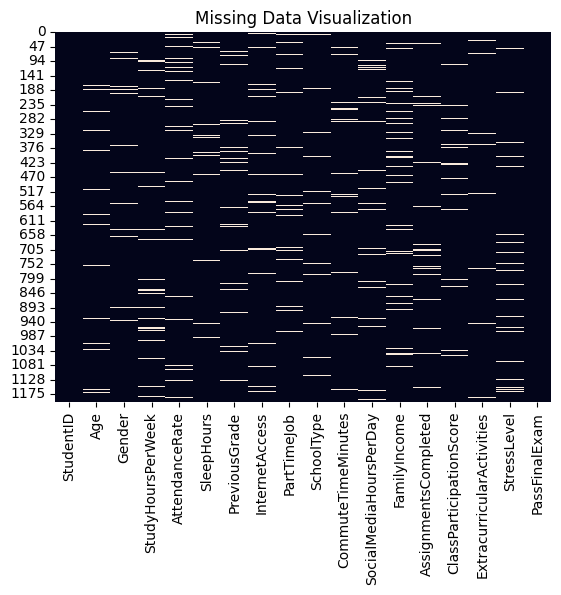

In [10]:
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Data Visualization")
plt.show()

Data Cleaning

In [11]:
df["Gender"] = df["Gender"].str.lower()

df["Gender"] = df["Gender"].replace({
    "m":"male",
    "f":"female"
})

In [12]:
df["InternetAccess"] = df["InternetAccess"].str.lower()

df["InternetAccess"] = df["InternetAccess"].replace({
    "y":"yes",
    "n":"no"
})

In [13]:
df["PartTimeJob"] = df["PartTimeJob"].str.lower()

In [14]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [15]:
df.fillna("unknown", inplace=True)

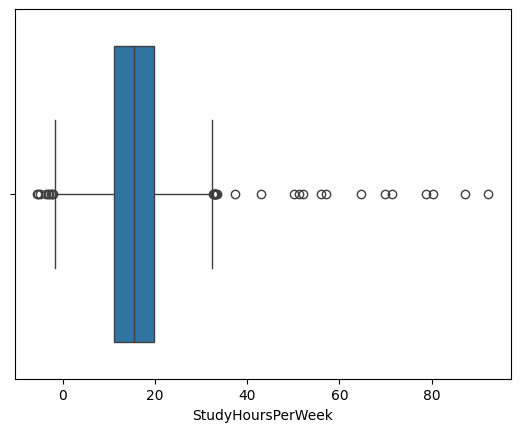

In [16]:
sns.boxplot(x=df["StudyHoursPerWeek"])
plt.show()

In [17]:
df = df[df["StudyHoursPerWeek"] < 60]

Feature Engineering

In [18]:
df["StudyEfficiency"] = df["PreviousGrade"] / df["StudyHoursPerWeek"]

In [19]:
df["LifestyleScore"] = df["SleepHours"] - df["StressLevel"]

Encode Categorical Variables - Machine learning models need numbers.

In [20]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

Feature Correlation

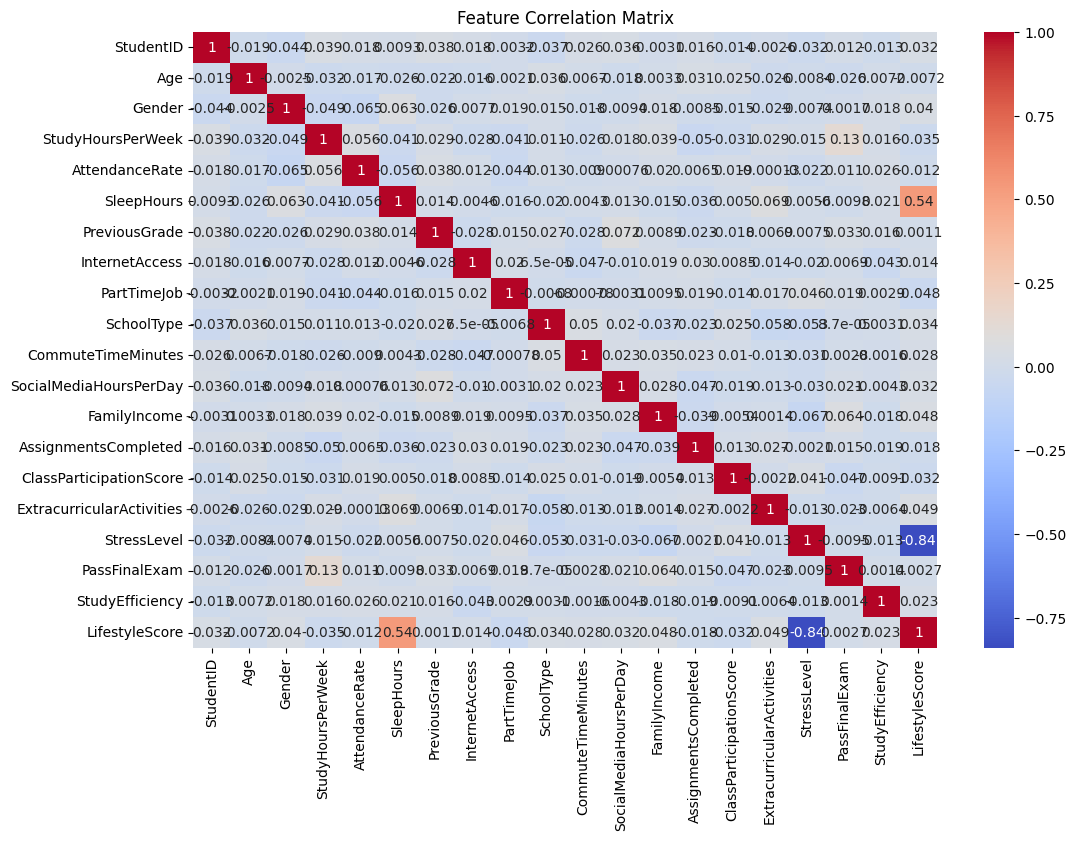

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

Train/Test Split

In [22]:
X = df.drop("PassFinalExam",axis=1)
y = df["PassFinalExam"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

Train Machine Learning Model

In [23]:
model = RandomForestClassifier()

model.fit(X_train,y_train)

RandomForestClassifier()

In [24]:
predictions = model.predict(X_test)

In [25]:
accuracy_score(y_test,predictions)

0.9748953974895398

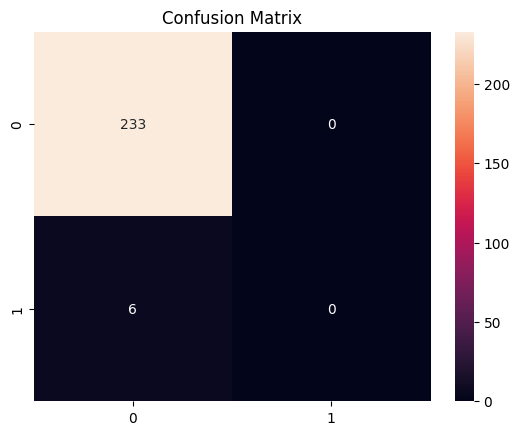

In [26]:
cm = confusion_matrix(y_test,predictions)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [27]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       233
           1       0.00      0.00      0.00         6

    accuracy                           0.97       239
   macro avg       0.49      0.50      0.49       239
weighted avg       0.95      0.97      0.96       239



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Feature Importance

This shows which variables matter most.

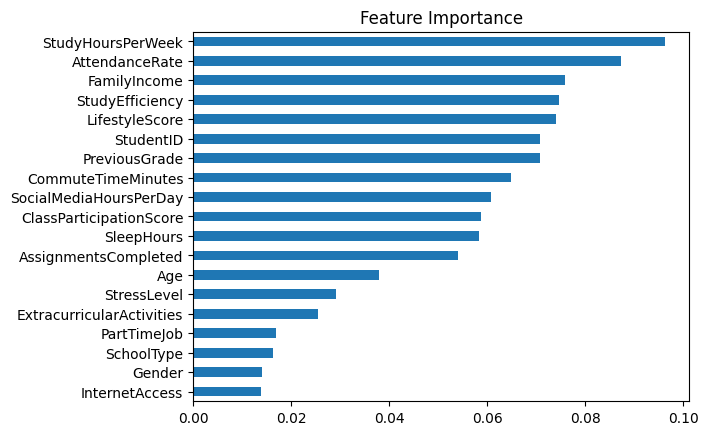

In [28]:
importances = model.feature_importances_

feature_importance = pd.Series(importances,index=X.columns)

feature_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()